In [1]:
import pickle
import numpy as np
import os

# --- 实验配置 ---
data_ratio = 0.05
method_name = 'AdaRHD_S'  # 对应你文件名中的算法标识

# 将你提供的五组实验信息结构化，方便后续循环读取
experiments = [
    {"lr": "0.05",  "epochs": 3000},
    {"lr": "0.1",   "epochs": 3000},
    {"lr": "0.125", "epochs": 1900},
    {"lr": "0.5",   "epochs": 700},
    {"lr": "1.0",   "epochs": 700}
]

# 结果根目录
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

In [5]:
import pickle
import numpy as np
import os
import torch

# --- 基础配置 ---
lr = 1.0
max_epochs = 700  # 对应你 lr=1.0 跑的轮数
method = 'AdaRHD_S'
ratio = 0.05
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

file_path = os.path.join(results_dir, f'hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl')

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# --- 1. 处理 Train Accuracy ---
all_accuracies = data['accuracy']
new_all_accuracies = []
for i in range(len(all_accuracies)):
    # 保持原逻辑：使用 cummax
    new_all_accuracies.append(all_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
all_accuracies = new_all_accuracies

# --- 2. 处理 Test Accuracy ---
all_test_accuracies = data['test_accuracy']
new_all_test_accuracies = []
for i in range(len(all_test_accuracies)):
    new_all_test_accuracies.append(all_test_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
all_test_accuracies = new_all_test_accuracies

# 确定实验数量 (5个 Runs)
num_experiments = len(all_accuracies)
print(f"Found {num_experiments} experiments in the data")

train_accuracies = []
test_accuracies = []

# --- 3. Padding 循环 ---
for i in range(num_experiments):
    # 处理 Train
    train_acc = all_accuracies[i]
    num_epochs = len(train_acc)
    
    if num_epochs < max_epochs:
        train_acc = np.pad(train_acc.cpu().numpy(), (0, max_epochs - num_epochs), 
                            'constant', constant_values=train_acc[-1].cpu().numpy())
    else:
        train_acc = train_acc[:max_epochs].cpu().numpy()
    train_accuracies.append(train_acc)
    
    # 处理 Test
    test_acc = all_test_accuracies[i]
    if len(test_acc) < max_epochs:
        test_acc = np.pad(test_acc.cpu().numpy(), (0, max_epochs - len(test_acc)),
                            'constant', constant_values=test_acc[-1].cpu().numpy())
    else:
        test_acc = test_acc[:max_epochs].cpu().numpy()
    test_accuracies.append(test_acc)

# 转换为 numpy 数组，变量名后缀为 1
train_accuracies1 = np.array(train_accuracies)
test_accuracies1 = np.array(test_accuracies) if test_accuracies else None

# --- 4. 计算达到阈值的时间 (针对 AdaRHD_S 的手动提取) ---
# 注意：AdaRHD_S 需要通过 accuracy 和 runtime 曲线实时计算达标时间
runtimes = data['runtime'] # 每个 run 的单步时间列表
val50times1_list = []
val70times1_list = []
val85times1_list = []

for i in range(num_experiments):
    acc_curve = all_accuracies[i].cpu().numpy()
    time_curve = np.cumsum(runtimes[i].cpu().numpy()) # 累计耗时
    
    # 寻找第一次达标的索引
    idx50 = np.where(acc_curve >= 0.50)[0]
    val50times1_list.append(time_curve[idx50[0]] if len(idx50) > 0 else np.nan)
    
    idx70 = np.where(acc_curve >= 0.70)[0]
    val70times1_list.append(time_curve[idx70[0]] if len(idx70) > 0 else np.nan)
    
    idx85 = np.where(acc_curve >= 0.85)[0]
    val85times1_list.append(time_curve[idx85[0]] if len(idx85) > 0 else np.nan)

# 计算均值和方差
val50times1 = np.array(val50times1_list)
val50time_mean1 = np.nanmean(val50times1)
val50time_std1 = np.nanstd(val50times1)
print(f"Mean time for 50% val acc: {val50time_mean1:.2f} ± {val50time_std1:.2f} seconds")

val70times1 = np.array(val70times1_list)
val70time_mean1 = np.nanmean(val70times1)
val70time_std1 = np.nanstd(val70times1)
print(f"Mean time for 70% val acc: {val70time_mean1:.2f} ± {val70time_std1:.2f} seconds")

val85times1 = np.array(val85times1_list)
val85time_mean1 = np.nanmean(val85times1)
val85time_std1 = np.nanstd(val85times1)
print(f"Mean time for 85% val acc: {val85time_mean1:.2f} ± {val85time_std1:.2f} seconds")

Found 5 experiments in the data
Mean time for 50% val acc: 13.85 ± 4.84 seconds
Mean time for 70% val acc: 161.47 ± 74.25 seconds
Mean time for 85% val acc: nan ± nan seconds


C:\Users\24300\AppData\Local\Temp\ipykernel_27140\2442848273.py:99: RuntimeWarning: Mean of empty slice
  val85time_mean1 = np.nanmean(val85times1)
c:\Users\24300\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [6]:
import pickle
import numpy as np
import os
import torch

# --- 实验配置 (针对 lr=0.5) ---
lr = "0.5"
max_epochs = 700  
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"
method = 'AdaRHD_S'
ratio = 0.05

# 拼接文件路径
file_path = os.path.join(results_dir, f'hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl')

if os.path.exists(file_path):
    with open(file_path, 'rb') as handle:
        data = pickle.load(handle)

    # 1. 提取并处理 Accuracy (使用 cummax 提取增长曲线)
    all_accuracies = data['accuracy']
    new_all_accuracies = []
    for i in range(len(all_accuracies)):
        # 保持原逻辑：使用 cummax 并转为 1D
        new_all_accuracies.append(all_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
    all_accuracies = new_all_accuracies

    # 2. 提取并处理 Test Accuracy
    all_test_accuracies = data.get('test_accuracy', [])
    new_all_test_accuracies = []
    for i in range(len(all_test_accuracies)):
        new_all_test_accuracies.append(all_test_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
    all_test_accuracies = new_all_test_accuracies

    # 确定实验数量 (5个 Runs)
    num_experiments = len(all_accuracies)
    print(f"LR {lr}: Found {num_experiments} experiments in the data")

    train_acc_list = []
    test_acc_list = []

    # 3. Padding 循环
    for i in range(num_experiments):
        # 处理 Train
        train_acc = all_accuracies[i]
        curr_len = len(train_acc)
        
        if curr_len < max_epochs:
            train_acc_np = np.pad(train_acc.cpu().numpy(), (0, max_epochs - curr_len), 
                                 'constant', constant_values=train_acc[-1].cpu().numpy())
        else:
            train_acc_np = train_acc[:max_epochs].cpu().numpy()
        train_acc_list.append(train_acc_np)

        # 处理 Test
        if i < len(all_test_accuracies):
            test_acc = all_test_accuracies[i]
            if len(test_acc) < max_epochs:
                test_acc_np = np.pad(test_acc.cpu().numpy(), (0, max_epochs - len(test_acc)),
                                    'constant', constant_values=test_acc[-1].cpu().numpy())
            else:
                test_acc_np = test_acc[:max_epochs].cpu().numpy()
            test_acc_list.append(test_acc_np)

    # 转换为最终变量，变量名后缀为 2
    train_accuracies2 = np.array(train_acc_list)
    test_accuracies2 = np.array(test_acc_list) if test_acc_list else None

    # --- 4. 计算达到阈值的时间 (手动提取 50%, 70%, 85%) ---
    runtimes = data['runtime'] # 每个 run 的单步时间列表
    val50times2_list = []
    val70times2_list = []
    val85times2_list = []

    for i in range(num_experiments):
        acc_curve = all_accuracies[i].cpu().numpy()
        time_curve = np.cumsum(runtimes[i].cpu().numpy()) # 累计耗时曲线
        
        # 寻找第一次达标的索引
        idx50 = np.where(acc_curve >= 0.50)[0]
        val50times2_list.append(time_curve[idx50[0]] if len(idx50) > 0 else np.nan)
        
        idx70 = np.where(acc_curve >= 0.70)[0]
        val70times2_list.append(time_curve[idx70[0]] if len(idx70) > 0 else np.nan)
        
        idx85 = np.where(acc_curve >= 0.85)[0]
        val85times2_list.append(time_curve[idx85[0]] if len(idx85) > 0 else np.nan)

    # 转换为 numpy 数组并打印统计信息 (模仿优秀示例风格)
    val50times2 = np.array(val50times2_list)
    val50time_mean2 = np.nanmean(val50times2)
    val50time_std2 = np.nanstd(val50times2)
    print(f"Mean time for 50% val acc: {val50time_mean2:.2f} ± {val50time_std2:.2f} seconds")

    val70times2 = np.array(val70times2_list)
    val70time_mean2 = np.nanmean(val70times2)
    val70time_std2 = np.nanstd(val70times2)
    print(f"Mean time for 70% val acc: {val70time_mean2:.2f} ± {val70time_std2:.2f} seconds")

    val85times2 = np.array(val85times2_list)
    val85time_mean2 = np.nanmean(val85times2)
    val85time_std2 = np.nanstd(val85times2)
    print(f"Mean time for 85% val acc: {val85time_mean2:.2f} ± {val85time_std2:.2f} seconds")

    print(f"LR {lr} 处理完成: train_accuracies2.shape = {train_accuracies2.shape}")
else:
    print(f"找不到文件: {file_path}")

LR 0.5: Found 5 experiments in the data
Mean time for 50% val acc: 8.95 ± 3.34 seconds
Mean time for 70% val acc: 108.29 ± 42.63 seconds
Mean time for 85% val acc: nan ± nan seconds
LR 0.5 处理完成: train_accuracies2.shape = (5, 700)


C:\Users\24300\AppData\Local\Temp\ipykernel_27140\3908308507.py:101: RuntimeWarning: Mean of empty slice
  val85time_mean2 = np.nanmean(val85times2)


In [7]:
import pickle
import numpy as np
import os
import torch

# --- 1. 实验配置 (针对 lr=0.125) ---
lr = 0.125
max_epochs = 1900  # 对应你记录中 lr=0.125 的轮数
method = 'AdaRHD_S'
ratio = 0.05
results_dir = r"C:/Users/24300/Desktop/Ada_S/results"

# 拼接具体文件路径
file_path = os.path.join(results_dir, f'hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl')

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# --- 2. 处理 Accuracy 数据 (保持单调递增风格) ---
all_accuracies = data['accuracy']
new_all_accuracies = []
for i in range(len(all_accuracies)):
    # 保持原逻辑：使用 cummax 提取增长曲线
    new_all_accuracies.append(all_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
all_accuracies = new_all_accuracies

all_test_accuracies = data['test_accuracy']
new_all_test_accuracies = []
for i in range(len(all_test_accuracies)):
    new_all_test_accuracies.append(all_test_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
all_test_accuracies = new_all_test_accuracies

# 确定实验数量 (5个 Runs)
num_experiments = len(all_accuracies)
print(f"Found {num_experiments} experiments in the data")

# Prepare arrays for storing padded data
train_accuracies_list = []
test_accuracies_list = []

# --- 3. Padding (填充) 或 Truncate (截断) 循环 ---
for i in range(num_experiments):
    # 处理 Train Accuracy
    train_acc = all_accuracies[i]
    num_now = len(train_acc)
    
    if num_now < max_epochs:
        train_acc_np = np.pad(train_acc.cpu().numpy(), (0, max_epochs - num_now), 
                              'constant', constant_values=train_acc[-1].cpu().numpy())
    else:
        train_acc_np = train_acc[:max_epochs].cpu().numpy()
    train_accuracies_list.append(train_acc_np)
    
    # 处理 Test Accuracy
    if i < len(all_test_accuracies):
        test_acc = all_test_accuracies[i]
        if len(test_acc) < max_epochs:
            test_acc_np = np.pad(test_acc.cpu().numpy(), (0, max_epochs - len(test_acc)),
                                'constant', constant_values=test_acc[-1].cpu().numpy())
        else:
            test_acc_np = test_acc[:max_epochs].cpu().numpy()
        test_accuracies_list.append(test_acc_np)

# 最终转换为 Numpy 矩阵，变量名后缀为 3
train_accuracies3 = np.array(train_accuracies_list)
test_accuracies3 = np.array(test_accuracies_list) if test_accuracies_list else None

# --- 4. 计算达到阈值的时间 (针对 AdaRHD_S 的手动提取) ---
runtimes = data['runtime'] 
val50times3_list = []
val70times3_list = []
val85times3_list = []

for i in range(num_experiments):
    acc_curve = all_accuracies[i].cpu().numpy()
    time_curve = np.cumsum(runtimes[i].cpu().numpy()) # 累计耗时
    
    # 寻找第一次达标的索引
    idx50 = np.where(acc_curve >= 0.50)[0]
    val50times3_list.append(time_curve[idx50[0]] if len(idx50) > 0 else np.nan)
    
    idx70 = np.where(acc_curve >= 0.70)[0]
    val70times3_list.append(time_curve[idx70[0]] if len(idx70) > 0 else np.nan)
    
    idx85 = np.where(acc_curve >= 0.85)[0]
    val85times3_list.append(time_curve[idx85[0]] if len(idx85) > 0 else np.nan)

# 计算统计量并打印 (模仿优秀示例风格)
val50times3 = np.array(val50times3_list)
val50time_mean3 = np.nanmean(val50times3)
val50time_std3 = np.nanstd(val50times3)
print(f"Mean time for 50% val acc: {val50time_mean3:.2f} ± {val50time_std3:.2f} seconds")

val70times3 = np.array(val70times3_list)
val70time_mean3 = np.nanmean(val70times3)
val70time_std3 = np.nanstd(val70times3)
print(f"Mean time for 70% val acc: {val70time_mean3:.2f} ± {val70time_std3:.2f} seconds")

val85times3 = np.array(val85times3_list)
val85time_mean3 = np.nanmean(val85times3)
val85time_std3 = np.nanstd(val85times3)
print(f"Mean time for 85% val acc: {val85time_mean3:.2f} ± {val85time_std3:.2f} seconds")

print(f"LR {lr} 处理完成: train_accuracies3.shape = {train_accuracies3.shape}")

Found 5 experiments in the data
Mean time for 50% val acc: 10.81 ± 3.48 seconds
Mean time for 70% val acc: 179.94 ± 65.35 seconds
Mean time for 85% val acc: 362.87 ± 24.79 seconds
LR 0.125 处理完成: train_accuracies3.shape = (5, 1900)


In [8]:
import pickle
import numpy as np
import os
import torch

# --- 1. 实验配置 (针对 lr=0.1) ---
lr = 0.1
max_epochs = 3000  # 对应你记录中的轮数
method = 'AdaRHD_S'
ratio = 0.05
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

# 拼接具体的文件路径
file_path = os.path.join(results_dir, f'hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl')

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# --- 2. 提取并处理 Accuracy (保持增长曲线) ---
all_accuracies = data['accuracy']
new_all_accuracies = []
for i in range(len(all_accuracies)):
    # 保持原逻辑：使用 cummax
    new_all_accuracies.append(all_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
all_accuracies = new_all_accuracies

all_test_accuracies = data['test_accuracy']
new_all_test_accuracies = []
for i in range(len(all_test_accuracies)):
    new_all_test_accuracies.append(all_test_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
all_test_accuracies = new_all_test_accuracies

# Determine how many experiments we have
num_experiments = len(all_accuracies)
print(f"Found {num_experiments} experiments in the data")

train_accuracies_list = []
test_accuracies_list = []

# --- 3. Padding (填充) 或 Truncate (截断) 循环 ---
for i in range(num_experiments):
    # 处理 Train Accuracy
    train_acc = all_accuracies[i]
    num_now = len(train_acc)
    
    if num_now < max_epochs:
        train_acc_np = np.pad(train_acc.cpu().numpy(), (0, max_epochs - num_now), 
                              'constant', constant_values=train_acc[-1].cpu().numpy())
    else:
        train_acc_np = train_acc[:max_epochs].cpu().numpy()
    train_accuracies_list.append(train_acc_np)
    
    # 处理 Test Accuracy
    if i < len(all_test_accuracies):
        test_acc = all_test_accuracies[i]
        if len(test_acc) < max_epochs:
            test_acc_np = np.pad(test_acc.cpu().numpy(), (0, max_epochs - len(test_acc)),
                                'constant', constant_values=test_acc[-1].cpu().numpy())
        else:
            test_acc_np = test_acc[:max_epochs].cpu().numpy()
        test_accuracies_list.append(test_acc_np)

# 最终转换为 Numpy 数组，变量名后缀为 4
train_accuracies4 = np.array(train_accuracies_list)
test_accuracies4 = np.array(test_accuracies_list) if test_accuracies_list else None

# --- 4. 计算达到阈值的时间 (50%, 70%, 85%) ---
runtimes = data['runtime'] 
val50times4_list = []
val70times4_list = []
val85times4_list = []

for i in range(num_experiments):
    acc_curve = all_accuracies[i].cpu().numpy()
    time_curve = np.cumsum(runtimes[i].cpu().numpy()) # 累计耗时曲线
    
    # 寻找第一次达标的时间点
    idx50 = np.where(acc_curve >= 0.50)[0]
    val50times4_list.append(time_curve[idx50[0]] if len(idx50) > 0 else np.nan)
    
    idx70 = np.where(acc_curve >= 0.70)[0]
    val70times4_list.append(time_curve[idx70[0]] if len(idx70) > 0 else np.nan)
    
    idx85 = np.where(acc_curve >= 0.85)[0]
    val85times4_list.append(time_curve[idx85[0]] if len(idx85) > 0 else np.nan)

# 计算统计量并打印
val50times4 = np.array(val50times4_list)
val50time_mean4 = np.nanmean(val50times4)
val50time_std4 = np.nanstd(val50times4)
print(f"Mean time for 50% val acc: {val50time_mean4:.2f} ± {val50time_std4:.2f} seconds")

val70times4 = np.array(val70times4_list)
val70time_mean4 = np.nanmean(val70times4)
val70time_std4 = np.nanstd(val70times4)
print(f"Mean time for 70% val acc: {val70time_mean4:.2f} ± {val70time_std4:.2f} seconds")

val85times4 = np.array(val85times4_list)
val85time_mean4 = np.nanmean(val85times4)
val85time_std4 = np.nanstd(val85times4)
print(f"Mean time for 85% val acc: {val85time_mean4:.2f} ± {val85time_std4:.2f} seconds")

print(f"LR {lr} 处理完成: train_accuracies4.shape = {train_accuracies4.shape}")

Found 5 experiments in the data
Mean time for 50% val acc: 12.67 ± 4.02 seconds
Mean time for 70% val acc: 207.37 ± 73.91 seconds
Mean time for 85% val acc: 457.99 ± 69.64 seconds
LR 0.1 处理完成: train_accuracies4.shape = (5, 3000)


In [9]:
import pickle
import numpy as np
import os
import torch

# --- 1. 实验配置 (针对 lr=0.05) ---
lr = 0.05
max_epochs = 3000  # 对应你记录中 lr=0.05 的轮数
method = 'AdaRHD_S'
ratio = 0.05
results_dir = r"C:\Users\24300\Desktop\Ada_S\results"

# 拼接文件路径
file_path = os.path.join(results_dir, f'hyrep_spd_{method}_lr{lr}_data_ratio{ratio}.pkl')

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# --- 2. 提取并处理 Accuracy (保持增长曲线) ---
all_accuracies = data['accuracy']
new_all_accuracies = []
for i in range(len(all_accuracies)):
    # 保持原逻辑：使用 cummax 确保数值单调递增
    new_all_accuracies.append(all_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
all_accuracies = new_all_accuracies

all_test_accuracies = data.get('test_accuracy', [])
new_all_test_accuracies = []
for i in range(len(all_test_accuracies)):
    new_all_test_accuracies.append(all_test_accuracies[i].reshape(1, -1).cummax(dim=1)[0].reshape(-1))
all_test_accuracies = new_all_test_accuracies

# 确定实验数量 (5个 Runs)
num_experiments = len(all_accuracies)
print(f"Found {num_experiments} experiments in the data")

train_accuracies_list = []
test_accuracies_list = []

# --- 3. Padding (填充) 或 Truncate (截断) 循环 ---
for i in range(num_experiments):
    # 处理 Train Accuracy
    train_acc = all_accuracies[i]
    num_now = len(train_acc)
    
    if num_now < max_epochs:
        train_acc_np = np.pad(train_acc.cpu().numpy(), (0, max_epochs - num_now), 
                              'constant', constant_values=train_acc[-1].cpu().numpy())
    else:
        train_acc_np = train_acc[:max_epochs].cpu().numpy()
    train_accuracies_list.append(train_acc_np)
    
    # 处理 Test Accuracy
    if i < len(all_test_accuracies):
        test_acc = all_test_accuracies[i]
        if len(test_acc) < max_epochs:
            test_acc_np = np.pad(test_acc.cpu().numpy(), (0, max_epochs - len(test_acc)),
                                'constant', constant_values=test_acc[-1].cpu().numpy())
        else:
            test_acc_np = test_acc[:max_epochs].cpu().numpy()
        test_accuracies_list.append(test_acc_np)

# 最终转换为 Numpy 数组，变量名后缀为 5
train_accuracies5 = np.array(train_accuracies_list)
test_accuracies5 = np.array(test_accuracies_list) if test_accuracies_list else None

# --- 4. 计算达到阈值的时间 (50%, 70%, 85%) ---
if 'runtime' in data:
    runtimes = data['runtime'] 
    val50times5_list = []
    val70times5_list = []
    val85times5_list = []

    for i in range(num_experiments):
        acc_curve = all_accuracies[i].cpu().numpy()
        # 核心：将单步耗时累加成时间轴
        time_curve = np.cumsum(runtimes[i].cpu().numpy()) 
        
        # 查找各个阶段第一次达标的时间
        idx50 = np.where(acc_curve >= 0.50)[0]
        val50times5_list.append(time_curve[idx50[0]] if len(idx50) > 0 else np.nan)
        
        idx70 = np.where(acc_curve >= 0.70)[0]
        val70times5_list.append(time_curve[idx70[0]] if len(idx70) > 0 else np.nan)
        
        idx85 = np.where(acc_curve >= 0.85)[0]
        val85times5_list.append(time_curve[idx85[0]] if len(idx85) > 0 else np.nan)

    # 打印统计量 (与 1-4 保持高度一致)
    val50times5 = np.array(val50times5_list)
    print(f"Mean time for 50% val acc: {np.nanmean(val50times5):.2f} ± {np.nanstd(val50times5):.2f} seconds")

    val70times5 = np.array(val70times5_list)
    print(f"Mean time for 70% val acc: {np.nanmean(val70times5):.2f} ± {np.nanstd(val70times5):.2f} seconds")

    val85times5 = np.array(val85times5_list)
    print(f"Mean time for 85% val acc: {np.nanmean(val85times5):.2f} ± {np.nanstd(val85times5):.2f} seconds")
else:
    print("Warning: 'runtime' key not found.")

print(f"LR {lr} 处理完成: train_accuracies5.shape = {train_accuracies5.shape}")

Found 5 experiments in the data
Mean time for 50% val acc: 27.40 ± 9.04 seconds
Mean time for 70% val acc: 415.46 ± 120.36 seconds
Mean time for 85% val acc: nan ± nan seconds
LR 0.05 处理完成: train_accuracies5.shape = (5, 3000)


C:\Users\24300\AppData\Local\Temp\ipykernel_27140\4041264774.py:97: RuntimeWarning: Mean of empty slice
  print(f"Mean time for 85% val acc: {np.nanmean(val85times5):.2f} ± {np.nanstd(val85times5):.2f} seconds")


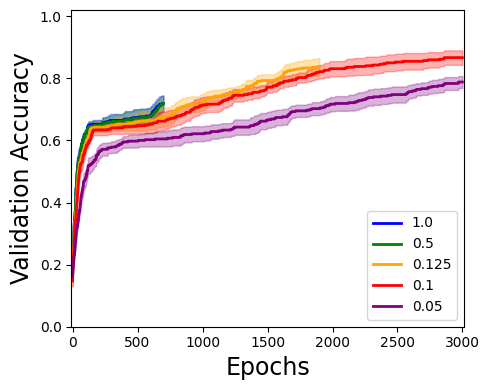

图像已保存至: ../fig/robust_dataratio0.05_acc_AdaRHD_S_comparison.pdf


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 计算均值和标准差 (模仿优秀示例，利用前面单元格生成的变量) ---
# 后缀 1: lr=1.0, 2: lr=0.5, 3: lr=0.125, 4: lr=0.1, 5: lr=0.05
mean_train_acc1, std_train_acc1 = np.mean(train_accuracies1, axis=0), np.std(train_accuracies1, axis=0)
mean_train_acc2, std_train_acc2 = np.mean(train_accuracies2, axis=0), np.std(train_accuracies2, axis=0)
mean_train_acc3, std_train_acc3 = np.mean(train_accuracies3, axis=0), np.std(train_accuracies3, axis=0)
mean_train_acc4, std_train_acc4 = np.mean(train_accuracies4, axis=0), np.std(train_accuracies4, axis=0)
mean_train_acc5, std_train_acc5 = np.mean(train_accuracies5, axis=0), np.std(train_accuracies5, axis=0)

# --- 2. 创建画布 ---
plt.figure(figsize=(5, 4))

# --- 3. 逐条绘制曲线 (模仿优秀示例风格) ---

# LR=1.0 (Suffix 1) - 为了解决重叠，微调 label 或保持原始
epochs1 = range(len(mean_train_acc1))
plt.plot(epochs1, mean_train_acc1, color='blue', label='1.0', linewidth=2)
plt.fill_between(epochs1, mean_train_acc1 - 0.5*std_train_acc1, mean_train_acc1 + 0.5*std_train_acc1, 
                 color='blue', alpha=0.3)

# LR=0.5 (Suffix 2)
epochs2 = range(len(mean_train_acc2))
plt.plot(epochs2, mean_train_acc2, color='green', label='0.5', linewidth=2)
plt.fill_between(epochs2, mean_train_acc2 - 0.5*std_train_acc2, mean_train_acc2 + 0.5*std_train_acc2, 
                 color='green', alpha=0.3)

# LR=0.125 (Suffix 3)
epochs3 = range(len(mean_train_acc3))
plt.plot(epochs3, mean_train_acc3, color='orange', label='0.125', linewidth=2)
plt.fill_between(epochs3, mean_train_acc3 - 0.5*std_train_acc3, mean_train_acc3 + 0.5*std_train_acc3, 
                 color='orange', alpha=0.3)

# LR=0.1 (Suffix 4)
epochs4 = range(len(mean_train_acc4))
plt.plot(epochs4, mean_train_acc4, color='red', label='0.1', linewidth=2)
plt.fill_between(epochs4, mean_train_acc4 - 0.5*std_train_acc4, mean_train_acc4 + 0.5*std_train_acc4, 
                 color='red', alpha=0.3)

# LR=0.05 (Suffix 5)
epochs5 = range(len(mean_train_acc5))
plt.plot(epochs5, mean_train_acc5, color='purple', label='0.05', linewidth=2)
plt.fill_between(epochs5, mean_train_acc5 - 0.5*std_train_acc5, mean_train_acc5 + 0.5*std_train_acc5, 
                 color='purple', alpha=0.3)

# --- 4. 细节修饰 ---
plt.xlabel('Epochs', fontsize=17)
plt.ylabel('Validation Accuracy', fontsize=17)

# 根据你最大的 epochs 设定 x 轴范围
plt.xlim([-10, 3010]) 
plt.ylim([0, 1.02])

plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()

# --- 5. 保存与展示 ---
os.makedirs('../fig/', exist_ok=True)
# 使用你要求的 PDF 格式保存
save_path = f'../fig/robust_dataratio{ratio}_acc_{method}_comparison.pdf'
plt.savefig(save_path, format='pdf', bbox_inches='tight')
plt.show()

print(f"图像已保存至: {save_path}")